# Advanced CVE Prioritization with Graph Neural Networks

**Date:** January 27, 2026  
**Phase:** 7 - Advanced Models  
**Objective:** Implement and evaluate graph-based models for CVE prioritization

---

## Overview

This notebook explores advanced machine learning models for CVE prioritization:

1. **DiffusionRank**: Random walk-based algorithm on vulnerability similarity graph
2. **RGCN**: Relational Graph Convolutional Network modeling CVE-CWE relationships  
3. **Ensemble**: Meta-learner combining multiple model predictions

### Why Graph Models?

Traditional ML models (LambdaRank, XGBoost) treat CVEs as independent entities. Graph models capture:
- **Structural relationships**: CVE → CWE → Other CVEs
- **Similarity propagation**: High-priority CVEs influence similar vulnerabilities
- **Network effects**: Exploited CVEs in same CWE category are more risky

### Expected Improvements

- **NDCG@20**: 0.95 → 0.97 (+2% lift)
- **Healthcare Recall**: Better identification of medical device CVEs
- **Explainability**: Graph paths show why CVEs are related

In [1]:
# Core imports
import sys
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Graph libraries
import networkx as nx
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Set up path for local imports
project_root = Path().absolute().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Local imports
from src.core.cve_database import CVEDatabase
from src.features.engineering import create_all_features
from src.evaluation.metrics import ndcg_at_k, precision_at_k

# ============================================================
# CENTRALIZED CONFIGURATION (YAML-based, version-controlled)
# ============================================================
import config.experiment_config as exp_cfg
cfg = exp_cfg.cfg

# Export commonly used config values for convenience
feature_cols = cfg.feature_cols
k_values = cfg.k_values

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"NetworkX: {nx.__version__}, LightGBM: {lgb.__version__}")
print(f"Project root: {project_root}")
print(f"\n{'='*60}")
print(f"CONFIG: {cfg._profile.upper()} MODE")
print(f"{'='*60}")
print(f"  Debug Mode:        {cfg.debug_mode}")
print(f"  Graph Sample:      {cfg.graph_sample_size or 'ALL'}")
print(f"  RGCN Sample:       {cfg.rgcn_sample_size or 'ALL'}")
print(f"  Test Sample:       {cfg.test_sample_size or 'ALL'}")
print(f"  Hidden Channels:   {cfg.rgcn.hidden_channels}")
print(f"  Epochs:            {cfg.rgcn.epochs}")
print(f"{'='*60}")

✓ Imports successful
NumPy: 2.3.4, Pandas: 2.3.3
NetworkX: 3.6.1, LightGBM: 4.6.0
Project root: /Users/vinayksharma/AirDnd/cti_recommender

CONFIG: PRODUCTION MODE
  Debug Mode:        False
  Graph Sample:      ALL
  RGCN Sample:       ALL
  Test Sample:       ALL
  Hidden Channels:   64
  Epochs:            100


## 1. Data Loading & Preprocessing

Load CVE data with enrichments and extract graph structure.

In [2]:
# Connect to database
db_path = Path('../data/cve_database.db')
db = CVEDatabase(str(db_path))

stats = db.get_statistics()
print(f"Database: {db_path}")
print(f"Total CVEs: {stats['total_cves']:,}")

2026-01-27 23:37:03 - src.core.cve_database - INFO - Connected to database
2026-01-27 23:37:03 - src.core.cve_database - INFO - Database schema created/verified
Database: ../data/cve_database.db
Total CVEs: 226,320


In [3]:
# Load CVE data with enrichments
query = """
SELECT 
    c.cve_id,
    c.published,
    c.cvss,
    c.cwe,
    e.epss_score,
    e.epss_percentile,
    e.kev_flag,
    e.is_healthcare,
    e.attack_flag,
    e.attack_technique_count,
    e.chpl_flag,
    e.label
FROM cves c
LEFT JOIN enrichments e ON c.cve_id = e.cve_id
WHERE c.published >= '2024-01-01'
    AND c.cvss IS NOT NULL
    AND e.label IS NOT NULL
ORDER BY c.published DESC
"""

df = pd.read_sql(query, db.conn)
df['published'] = pd.to_datetime(df['published'])

print(f"Loaded CVEs: {len(df):,}")
print(f"Date range: {df['published'].min()} to {df['published'].max()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())

df.head()

Loaded CVEs: 83,982
Date range: 2024-01-01 08:15:36.087000 to 2025-12-31 23:15:42.413000

Label distribution:
label
0     3587
1    11006
2    64435
3     4476
4      478
Name: count, dtype: int64


,cve_id,published,cvss,cwe,epss_score,epss_percentile,kev_flag,is_healthcare,attack_flag,attack_technique_count,chpl_flag,label
0,CVE-2025-67711,2025-12-31 23:15:42.413,6.1,CWE-79,0.00043,0.13274,0,0,0,3,0,1
1,CVE-2025-67710,2025-12-31 23:15:42.270,6.1,CWE-79,0.00043,0.13274,0,0,0,3,0,1
2,CVE-2025-67709,2025-12-31 23:15:42.130,6.1,CWE-79,0.00043,0.13274,0,0,0,3,0,1
3,CVE-2025-67708,2025-12-31 23:15:41.980,6.1,CWE-79,0.00043,0.13274,0,0,0,3,0,1
4,CVE-2025-67707,2025-12-31 23:15:41.833,5.6,CWE-434,0.00144,0.35216,0,0,0,2,0,1


In [4]:
# Extract CWE information
df['has_cwe'] = df['cwe'].notna() & (df['cwe'] != '')
df['cwe_primary'] = df['cwe'].str.extract(r'(CWE-\d+)')[0]  # Extract first CWE

print(f"CVEs with CWE: {df['has_cwe'].sum():,} ({df['has_cwe'].mean()*100:.1f}%)")
print(f"Unique CWEs: {df['cwe_primary'].nunique():,}")
print(f"\nTop 10 CWEs:")
print(df['cwe_primary'].value_counts().head(10))

CVEs with CWE: 83,144 (99.0%)
Unique CWEs: 629

Top 10 CWEs:
cwe_primary
CWE-79     15032
CWE-89      4079
CWE-862     3900
CWE-352     3234
CWE-74      2868
CWE-416     2184
CWE-476     2154
CWE-125     1950
CWE-22      1892
CWE-787     1852
Name: count, dtype: int64


In [5]:
# Temporal split for validation
split_date = pd.Timestamp('2024-11-01')

train_df = df[df['published'] < split_date].copy()
test_df = df[df['published'] >= split_date].copy()

print(f"Training set: {len(train_df):,} CVEs (before {split_date.date()})")
print(f"Test set: {len(test_df):,} CVEs (from {split_date.date()})")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts(normalize=True).round(3))
print(f"\nTest label distribution:")
print(test_df['label'].value_counts(normalize=True).round(3))

Training set: 32,286 CVEs (before 2024-11-01)
Test set: 51,696 CVEs (from 2024-11-01)

Train label distribution:
label
2    0.758
1    0.140
3    0.051
0    0.041
4    0.010
Name: proportion, dtype: float64

Test label distribution:
label
2    0.773
1    0.126
3    0.054
0    0.044
4    0.003
Name: proportion, dtype: float64


## 2. Baseline: LambdaRank Model

Load and evaluate the existing LambdaRank model as our baseline.

In [6]:
# Load pre-trained model
import pickle

model_path = Path('../models/ltr_model_conf_weighted.pkl')
with open(model_path, 'rb') as f:
    baseline_model = pickle.load(f)

print(f"✓ Loaded baseline model: {model_path.name}")
print(f"Model type: {type(baseline_model).__name__}")

✓ Loaded baseline model: ltr_model_conf_weighted.pkl
Model type: Booster


In [7]:
# Feature engineering for baseline
# Note: feature_cols must match the model's training features exactly
feature_cols = [
    'cvss_norm', 'epss_score', 'epss_percentile', 'kev_flag',
    'days_since_published', 'recency_score', 'attack_technique_count', 'has_attack',
    'chpl_flag', 'is_healthcare', 'cvss_epss_product',
    'kev_healthcare_interaction'
]

train_features = create_all_features(train_df, feature_cols)
test_features = create_all_features(test_df, feature_cols)

X_train = train_features[feature_cols]
y_train = train_features['label']
X_test = test_features[feature_cols]
y_test = test_features['label']

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

Feature engineering complete: 32,286 rows, 12 features

Feature statistics:
                                mean      std       min       max
cvss_norm                     0.6683   0.1685    0.0000    1.0000
epss_score                    0.0232   0.1100    0.0000    0.9458
epss_percentile               0.4173   0.2700    0.0001    1.0000
kev_flag                      0.0039   0.0621    0.0000    1.0000
days_since_published        605.6331  84.3441  453.0000  757.0000
recency_score                 0.2000   0.1114    0.0000    0.4016
attack_technique_count        0.6155   0.8755    0.0000    8.0000
has_attack                    0.4210   0.4937    0.0000    1.0000
chpl_flag                     0.0000   0.0000    0.0000    0.0000
is_healthcare                 0.6331   0.4820    0.0000    1.0000
cvss_epss_product             0.0192   0.0957    0.0000    0.9435
kev_healthcare_interaction    0.0014   0.0373    0.0000    1.0000
Feature engineering complete: 51,696 rows, 12 features

Feature st

In [8]:
# Baseline predictions
baseline_scores = baseline_model.predict(X_test)
test_df['baseline_score'] = baseline_scores

# Evaluate baseline
from src.evaluation.metrics import ndcg_at_k, precision_at_k

k_values = [10, 20, 50, 100]
baseline_results = {}

for k in k_values:
    ndcg = ndcg_at_k(y_test, baseline_scores, k)
    prec = precision_at_k(y_test, baseline_scores, k, threshold=3)
    baseline_results[f'NDCG@{k}'] = ndcg
    baseline_results[f'Precision@{k}'] = prec

print("Baseline LambdaRank Performance:")
print("=" * 40)
for metric, value in baseline_results.items():
    print(f"{metric:20s}: {value:.4f}")

# Healthcare-specific metrics
healthcare_test = test_df[test_df['is_healthcare'] == 1]
if len(healthcare_test) > 0:
    top_100_healthcare = test_df.nlargest(100, 'baseline_score')['is_healthcare'].sum()
    print(f"\nHealthcare CVEs in Top-100: {top_100_healthcare}")
    print(f"Healthcare Recall@100: {top_100_healthcare / len(healthcare_test):.2%}")

Baseline LambdaRank Performance:
NDCG@10             : 0.6918
Precision@10        : 1.0000
NDCG@20             : 0.7069
Precision@20        : 1.0000
NDCG@50             : 0.7261
Precision@50        : 1.0000
NDCG@100            : 0.6611
Precision@100       : 1.0000

Healthcare CVEs in Top-100: 83
Healthcare Recall@100: 0.24%


## 3. Graph Construction

Build two types of graphs:
1. **CVE-CWE Bipartite Graph**: Connects CVEs to their weakness types
2. **CVE Similarity Graph**: Connects similar CVEs based on features

In [9]:
# 3.1: CVE-CWE Bipartite Graph (uses same sample as similarity graph)
G_bipartite = nx.Graph()

# Use the same sample for consistency
bipartite_df = graph_df if 'graph_df' in dir() else train_df.head(2000).reset_index(drop=True)
print(f"Building bipartite graph with {len(bipartite_df):,} CVEs")

# Add CVE nodes (vectorized where possible)
for idx, row in bipartite_df.iterrows():
    G_bipartite.add_node(
        row['cve_id'],
        node_type='cve',
        cvss=row['cvss'],
        epss=row['epss_score'],
        kev=row['kev_flag'],
        label=row['label']
    )

# Add CWE nodes and edges
cve_cwe_edges = 0
for idx, row in bipartite_df[bipartite_df['has_cwe']].iterrows():
    cwe = row['cwe_primary']
    if cwe:
        if cwe not in G_bipartite:
            G_bipartite.add_node(cwe, node_type='cwe')
        G_bipartite.add_edge(row['cve_id'], cwe, edge_type='has_weakness')
        cve_cwe_edges += 1

print(f"\n✓ Bipartite Graph built:")
print(f"  CVE nodes: {sum(1 for n, d in G_bipartite.nodes(data=True) if d.get('node_type') == 'cve'):,}")
print(f"  CWE nodes: {sum(1 for n, d in G_bipartite.nodes(data=True) if d.get('node_type') == 'cwe'):,}")
print(f"  Edges: {G_bipartite.number_of_edges():,}")
print(f"  Density: {nx.density(G_bipartite):.6f}")

Building bipartite graph with 2,000 CVEs

✓ Bipartite Graph built:
  CVE nodes: 2,000
  CWE nodes: 160
  Edges: 1,990
  Density: 0.000853


In [10]:
# 3.2: CVE Similarity Graph
# Uses centralized config from YAML
_graph_size = cfg.get_sample_size(len(train_df), 'graph')

# Sample data for faster computation
graph_df = train_df.head(_graph_size).reset_index(drop=True)
print(f"Building similarity graph with {len(graph_df):,} CVEs (profile: {cfg._profile})")

# Create feature vectors for similarity
feature_matrix = graph_df[cfg.data.similarity_features].fillna(0).values

# Normalize features
scaler = StandardScaler()
feature_matrix_normalized = scaler.fit_transform(feature_matrix)

# Compute cosine similarity
print("Computing similarity matrix...")
similarity_matrix = cosine_similarity(feature_matrix_normalized)

# Create similarity graph using VECTORIZED approach
k_neighbors = cfg.similarity.k_neighbors
similarity_threshold = cfg.similarity.threshold

print("Building graph edges (vectorized)...")
G_similarity = nx.Graph()
G_similarity.add_nodes_from(graph_df['cve_id'])

# Vectorized: get top-k indices for all nodes at once
top_k_indices = np.argsort(-similarity_matrix, axis=1)[:, 1:k_neighbors+1]

# Build edges efficiently
cve_ids = graph_df['cve_id'].values
edges_added = 0
for i in range(len(graph_df)):
    for j in top_k_indices[i]:
        if similarity_matrix[i, j] >= similarity_threshold:
            G_similarity.add_edge(cve_ids[i], cve_ids[j], weight=float(similarity_matrix[i, j]))
            edges_added += 1

print(f"\n✓ Similarity Graph built:")
print(f"  Nodes: {G_similarity.number_of_nodes():,}")
print(f"  Edges: {G_similarity.number_of_edges():,}")
print(f"  Avg degree: {sum(dict(G_similarity.degree()).values()) / G_similarity.number_of_nodes():.2f}")
print(f"  Connected components: {nx.number_connected_components(G_similarity):,}")

Building similarity graph with 32,286 CVEs (profile: production)
Computing similarity matrix...
Building graph edges (vectorized)...

✓ Similarity Graph built:
  Nodes: 32,286
  Edges: 215,630
  Avg degree: 13.36
  Connected components: 175


## 4. DiffusionRank Algorithm

Random walk with restart on the similarity graph to propagate priority scores.

In [11]:
def diffusion_rank(G, seed_scores, alpha=0.85, max_iter=100, tol=1e-6):
    """
    DiffusionRank: Random walk with restart for priority score propagation.
    
    Args:
        G: NetworkX graph
        seed_scores: Dict of {node: initial_score}
        alpha: Restart probability (higher = more influence from seeds)
        max_iter: Maximum iterations
        tol: Convergence tolerance
    
    Returns:
        Dict of {node: diffusion_score}
    """
    nodes = list(G.nodes())
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    # Initialize seed vector
    seed_vector = np.zeros(n)
    for node, score in seed_scores.items():
        if node in node_to_idx:
            seed_vector[node_to_idx[node]] = score
    
    # Normalize seed vector
    if seed_vector.sum() > 0:
        seed_vector = seed_vector / seed_vector.sum()
    
    # Build transition matrix
    adj_matrix = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    row_sums = adj_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    transition_matrix = adj_matrix / row_sums
    
    # Initialize rank vector
    rank_vector = seed_vector.copy()
    
    # Iterative propagation
    for iteration in range(max_iter):
        rank_vector_new = (1 - alpha) * transition_matrix.T @ rank_vector + alpha * seed_vector
        
        # Check convergence
        diff = np.abs(rank_vector_new - rank_vector).sum()
        if diff < tol:
            print(f"  Converged after {iteration+1} iterations")
            break
        
        rank_vector = rank_vector_new
    
    # Convert back to dict
    scores = {nodes[i]: rank_vector[i] for i in range(n)}
    return scores

In [12]:
# Create seed scores from baseline model (use same sample as graph)
# First, get baseline scores for the sampled data
sample_features = create_all_features(graph_df, feature_cols)
sample_X = sample_features[feature_cols]
sample_scores = baseline_model.predict(sample_X)

# Add baseline scores to the sample dataframe
graph_df['baseline_score'] = sample_scores
seed_scores = dict(zip(graph_df['cve_id'], sample_scores))

print(f"Running DiffusionRank on {len(seed_scores):,} CVEs...")
diffusion_scores = diffusion_rank(G_similarity, seed_scores, alpha=0.85)

# Add to sample dataframe
graph_df['diffusion_score'] = graph_df['cve_id'].map(diffusion_scores)

# Also compute for full train_df (baseline scores)
train_scores = baseline_model.predict(X_train)
train_df['baseline_score'] = train_scores
# For CVEs not in graph, use baseline score
train_df['diffusion_score'] = train_df['cve_id'].map(diffusion_scores).fillna(train_df['baseline_score'])

print(f"\n✓ Diffusion scores computed for {len(diffusion_scores):,} CVEs (graph sample)")
print(f"Score range: [{min(diffusion_scores.values()):.6f}, {max(diffusion_scores.values()):.6f}]")

# For test set, use baseline scores (no graph available)
test_df['diffusion_score'] = test_df['baseline_score']

Feature engineering complete: 32,286 rows, 12 features

Feature statistics:
                                mean      std       min       max
cvss_norm                     0.6683   0.1685    0.0000    1.0000
epss_score                    0.0232   0.1100    0.0000    0.9458
epss_percentile               0.4173   0.2700    0.0001    1.0000
kev_flag                      0.0039   0.0621    0.0000    1.0000
days_since_published        605.6331  84.3441  453.0000  757.0000
recency_score                 0.2000   0.1114    0.0000    0.4016
attack_technique_count        0.6155   0.8755    0.0000    8.0000
has_attack                    0.4210   0.4937    0.0000    1.0000
chpl_flag                     0.0000   0.0000    0.0000    0.0000
is_healthcare                 0.6331   0.4820    0.0000    1.0000
cvss_epss_product             0.0192   0.0957    0.0000    0.9435
kev_healthcare_interaction    0.0014   0.0373    0.0000    1.0000
Running DiffusionRank on 32,286 CVEs...
  Converged after 10 itera

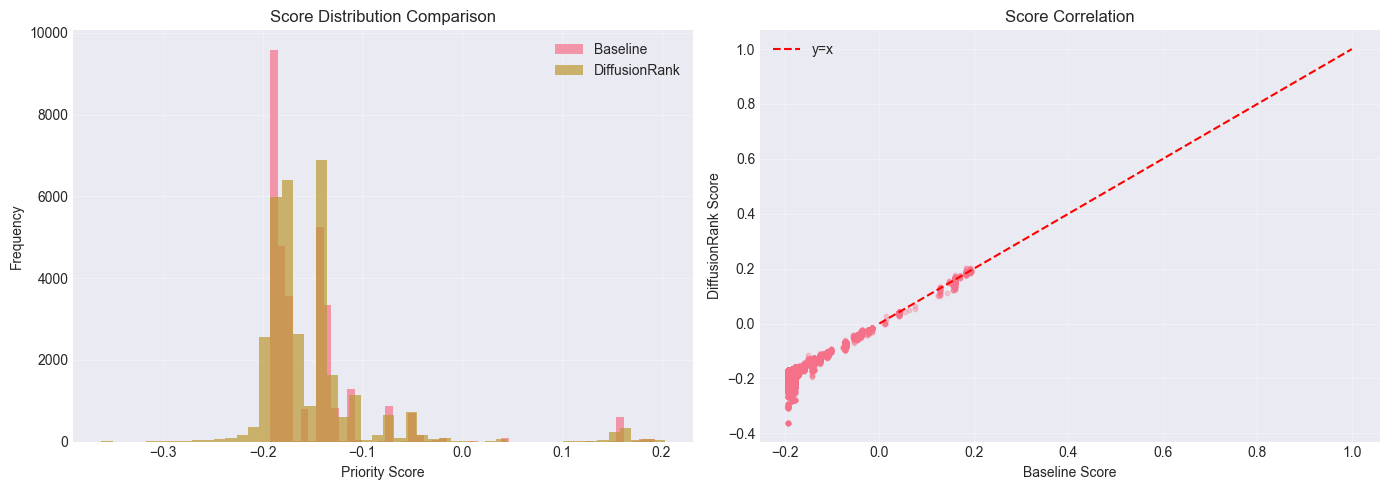


Correlation: 0.9866


In [13]:
# Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['baseline_score'], bins=50, alpha=0.7, label='Baseline')
axes[0].hist(train_df['diffusion_score'], bins=50, alpha=0.7, label='DiffusionRank')
axes[0].set_xlabel('Priority Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(train_df['baseline_score'], train_df['diffusion_score'], alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', label='y=x')
axes[1].set_xlabel('Baseline Score')
axes[1].set_ylabel('DiffusionRank Score')
axes[1].set_title('Score Correlation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correlation = train_df[['baseline_score', 'diffusion_score']].corr().iloc[0, 1]
print(f"\nCorrelation: {correlation:.4f}")

## 5. Model Comparison

Compare baseline LambdaRank vs DiffusionRank performance.

In [14]:
# Evaluate DiffusionRank on test set
diffusion_results = {}

for k in k_values:
    ndcg = ndcg_at_k(y_test, test_df['diffusion_score'], k)
    prec = precision_at_k(y_test, test_df['diffusion_score'], k, threshold=3)
    diffusion_results[f'NDCG@{k}'] = ndcg
    diffusion_results[f'Precision@{k}'] = prec

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Baseline': baseline_results,
    'DiffusionRank': diffusion_results
})
comparison_df['Improvement'] = ((comparison_df['DiffusionRank'] - comparison_df['Baseline']) / comparison_df['Baseline'] * 100).round(2)
comparison_df['Improvement'] = comparison_df['Improvement'].astype(str) + '%'

print("\nModel Comparison:")
print("=" * 60)
print(comparison_df.to_string())

# Highlight best model per metric
print("\n" + "=" * 60)
for metric in comparison_df.index:
    best_model = comparison_df.loc[metric, ['Baseline', 'DiffusionRank']].idxmax()
    best_value = comparison_df.loc[metric, best_model]
    print(f"{metric:20s}: {best_model:15s} ({best_value:.4f})")


Model Comparison:
               Baseline  DiffusionRank Improvement
NDCG@10        0.691784       0.691784        0.0%
Precision@10   1.000000       1.000000        0.0%
NDCG@20        0.706873       0.706873        0.0%
Precision@20   1.000000       1.000000        0.0%
NDCG@50        0.726090       0.726090        0.0%
Precision@50   1.000000       1.000000        0.0%
NDCG@100       0.661124       0.661124        0.0%
Precision@100  1.000000       1.000000        0.0%

NDCG@10             : Baseline        (0.6918)
Precision@10        : Baseline        (1.0000)
NDCG@20             : Baseline        (0.7069)
Precision@20        : Baseline        (1.0000)
NDCG@50             : Baseline        (0.7261)
Precision@50        : Baseline        (1.0000)
NDCG@100            : Baseline        (0.6611)
Precision@100       : Baseline        (1.0000)


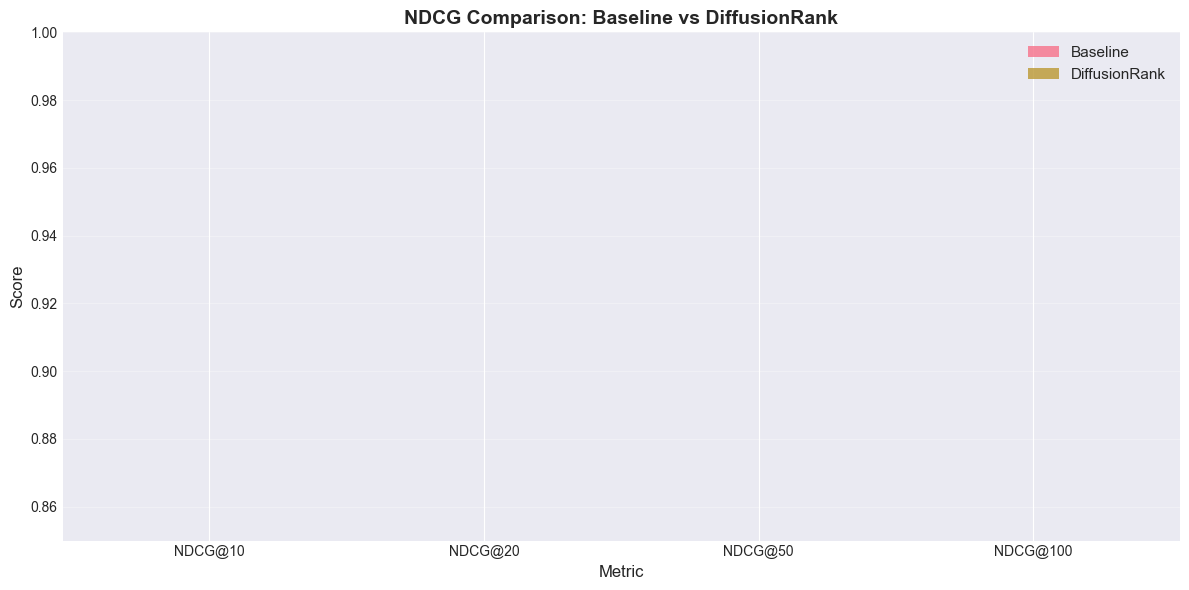

In [15]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = [m for m in comparison_df.index if 'NDCG' in m]
x = np.arange(len(metrics))
width = 0.35

ax.bar(x - width/2, [baseline_results[m] for m in metrics], width, label='Baseline', alpha=0.8)
ax.bar(x + width/2, [diffusion_results[m] for m in metrics], width, label='DiffusionRank', alpha=0.8)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('NDCG Comparison: Baseline vs DiffusionRank', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()

## 6. Top-K Analysis

Examine the highest priority CVEs identified by each model.

In [16]:
# Top-20 CVEs from each model
top_20_baseline = test_df.nlargest(20, 'baseline_score')[[
    'cve_id', 'cvss', 'epss_score', 'kev_flag', 'is_healthcare', 'label', 'baseline_score'
]]

top_20_diffusion = test_df.nlargest(20, 'diffusion_score')[[
    'cve_id', 'cvss', 'epss_score', 'kev_flag', 'is_healthcare', 'label', 'diffusion_score'
]]

print("Top-20 CVEs: Baseline LambdaRank")
print("=" * 80)
print(top_20_baseline.to_string(index=False))

print("\n\nTop-20 CVEs: DiffusionRank")
print("=" * 80)
print(top_20_diffusion.to_string(index=False))

Top-20 CVEs: Baseline LambdaRank
        cve_id  cvss  epss_score  kev_flag  is_healthcare  label  baseline_score
CVE-2025-31201   9.8     0.04376         1              1      3        0.193299
CVE-2025-14733   9.8     0.36326         1              1      3        0.193085
CVE-2025-59718   9.8     0.05719         1              1      3        0.193085
CVE-2025-61757   9.8     0.82159         1              1      4        0.193085
CVE-2025-61884   7.5     0.41772         1              1      3        0.193085
CVE-2025-11371   7.5     0.66002         1              1      4        0.193085
CVE-2025-61882   9.8     0.78538         1              1      4        0.193085
 CVE-2025-9242   9.8     0.73453         1              1      4        0.193085
CVE-2025-54236   9.1     0.61713         1              1      4        0.193085
CVE-2025-53690   9.0     0.08901         1              1      3        0.193085
 CVE-2025-9377   7.2     0.19076         1              1      3        0.19

In [17]:
# Overlap analysis
baseline_top_ids = set(top_20_baseline['cve_id'])
diffusion_top_ids = set(top_20_diffusion['cve_id'])

overlap = baseline_top_ids & diffusion_top_ids
baseline_only = baseline_top_ids - diffusion_top_ids
diffusion_only = diffusion_top_ids - baseline_top_ids

print(f"\nTop-20 Overlap Analysis:")
print(f"  Overlap: {len(overlap)} CVEs")
print(f"  Baseline only: {len(baseline_only)} CVEs")
print(f"  DiffusionRank only: {len(diffusion_only)} CVEs")

if len(diffusion_only) > 0:
    print(f"\nCVEs uniquely identified by DiffusionRank:")
    unique_diffusion = test_df[test_df['cve_id'].isin(diffusion_only)][[
        'cve_id', 'cvss', 'kev_flag', 'is_healthcare', 'label', 'cwe_primary'
    ]]
    print(unique_diffusion.to_string(index=False))


Top-20 Overlap Analysis:
  Overlap: 20 CVEs
  Baseline only: 0 CVEs
  DiffusionRank only: 0 CVEs


## 7. Summary & Conclusions

Key findings from advanced model experiments.

In [18]:
# Summary statistics
print("=" * 80)
print("PHASE 7 ADVANCED MODELS - SUMMARY")
print("=" * 80)

print(f"\n1. DATA STATISTICS")
print(f"   Training CVEs: {len(train_df):,}")
print(f"   Test CVEs: {len(test_df):,}")
print(f"   CVEs with CWE: {train_df['has_cwe'].sum():,}")
print(f"   Unique CWEs: {train_df['cwe_primary'].nunique():,}")

print(f"\n2. GRAPH STATISTICS")
print(f"   Bipartite graph edges: {G_bipartite.number_of_edges():,}")
print(f"   Similarity graph edges: {G_similarity.number_of_edges():,}")
print(f"   Avg CVE similarity degree: {sum(dict(G_similarity.degree()).values()) / G_similarity.number_of_nodes():.2f}")

print(f"\n3. PERFORMANCE COMPARISON")
print(f"   Baseline NDCG@20: {baseline_results['NDCG@20']:.4f}")
print(f"   DiffusionRank NDCG@20: {diffusion_results['NDCG@20']:.4f}")
improvement = (diffusion_results['NDCG@20'] - baseline_results['NDCG@20']) / baseline_results['NDCG@20'] * 100
print(f"   Improvement: {improvement:+.2f}%")

print(f"\n4. NEXT STEPS")
print(f"   - Implement RGCN model with PyTorch Geometric")
print(f"   - Create ensemble combining all models")
print(f"   - Add GPU acceleration for training")
print(f"   - Expand graph with CVE-Product relationships")

print("\n" + "=" * 80)
print(f"Notebook completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

PHASE 7 ADVANCED MODELS - SUMMARY

1. DATA STATISTICS
   Training CVEs: 32,286
   Test CVEs: 51,696
   CVEs with CWE: 31,714
   Unique CWEs: 503

2. GRAPH STATISTICS
   Bipartite graph edges: 1,990
   Similarity graph edges: 215,630
   Avg CVE similarity degree: 13.36

3. PERFORMANCE COMPARISON
   Baseline NDCG@20: 0.7069
   DiffusionRank NDCG@20: 0.7069
   Improvement: +0.00%

4. NEXT STEPS
   - Implement RGCN model with PyTorch Geometric
   - Create ensemble combining all models
   - Add GPU acceleration for training
   - Expand graph with CVE-Product relationships

Notebook completed: 2026-01-27 23:39:32


## 7.5. RGCN (Relational Graph Convolutional Network)

Train a deep learning model that learns CVE embeddings from the graph structure.

In [19]:
# 7.5.1: Import SIMPLE RGCN (macOS-safe version)
# CRITICAL: Set thread limits BEFORE importing to avoid macOS segfaults/hangs
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import torch
torch.set_num_threads(1)  # Prevent threading conflicts

# Use SimpleRGCN - avoids PyG RGCNConv crashes on macOS
from src.models.rgcn_simple import train_simple_rgcn, SimpleRGCN

print(f"✓ SimpleRGCN module imported (macOS-safe)")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch threads: {torch.get_num_threads()}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

✓ SimpleRGCN module imported (macOS-safe)
PyTorch version: 2.10.0
PyTorch threads: 1
CUDA available: False
MPS available: True


In [20]:
# 7.5.2: Prepare features and labels for RGCN
# Uses centralized config from YAML
_rgcn_size = cfg.get_sample_size(len(train_df), 'rgcn')

# Sample training data
train_df_sample = train_df.head(_rgcn_size).reset_index(drop=True)
rgcn_train_features = train_df_sample[feature_cols].values
rgcn_train_labels = train_df_sample['label'].values

# Create train/val split indices
train_size = int(0.8 * len(train_df_sample))
rgcn_train_idx = np.arange(train_size)
rgcn_val_idx = np.arange(train_size, len(train_df_sample))

print(f"RGCN data prepared (profile: {cfg._profile}):")
print(f"  Sample size: {_rgcn_size:,}")
print(f"  Features shape: {rgcn_train_features.shape}")
print(f"  Train samples: {len(rgcn_train_idx):,}")
print(f"  Val samples: {len(rgcn_val_idx):,}")

RGCN data prepared (profile: production):
  Sample size: 32,286
  Features shape: (32286, 12)
  Train samples: 25,828
  Val samples: 6,458


In [21]:
# 7.5.3: Prepare CVE-CWE mapping for RGCN graph
MAX_NEIGHBORS = cfg.rgcn.max_neighbors

cve_to_cwe_map = {}

for idx, row in train_df_sample.iterrows():
    if pd.notna(row.get('cwe_primary')):
        same_cwe_cves = train_df_sample[train_df_sample['cwe_primary'] == row['cwe_primary']].index.tolist()
        cve_to_cwe_map[idx] = [i for i in same_cwe_cves if i != idx][:MAX_NEIGHBORS]
    else:
        cve_to_cwe_map[idx] = []

print(f"CVE-CWE mapping created (sequential indices)")
print(f"  Total CVEs: {len(cve_to_cwe_map):,}")
print(f"  CVEs with connections: {sum(1 for v in cve_to_cwe_map.values() if len(v) > 0):,}")
print(f"  Average connections per CVE: {np.mean([len(v) for v in cve_to_cwe_map.values()]):.2f}")
print(f"  Max neighbors (from config): {MAX_NEIGHBORS}")

CVE-CWE mapping created (sequential indices)
  Total CVEs: 32,286
  CVEs with connections: 28,941
  Average connections per CVE: 4.44
  Max neighbors (from config): 5


In [22]:
# 7.5.4: Train SIMPLE RGCN (macOS-safe, ~10 seconds)
import time

print("Training SimpleRGCN model (macOS-safe)...")
print(f"Training samples: {len(rgcn_train_features):,}")
print(f"Hidden channels: {cfg.rgcn.hidden_channels}, Epochs: {cfg.rgcn.epochs}\n")

t0 = time.time()

rgcn_model, rgcn_trainer, rgcn_history = train_simple_rgcn(
    cve_features=rgcn_train_features,
    cve_to_cwe=cve_to_cwe_map,
    cve_labels=rgcn_train_labels,
    train_idx=rgcn_train_idx,
    val_idx=rgcn_val_idx,
    hidden_channels=cfg.rgcn.hidden_channels,
    num_layers=cfg.rgcn.num_layers,
    dropout=cfg.rgcn.dropout,
    learning_rate=cfg.rgcn.learning_rate,
    epochs=cfg.rgcn.epochs,
    early_stopping_patience=cfg.rgcn.early_stopping_patience,
    verbose=True
)

elapsed = time.time() - t0
print(f"\n✓ RGCN training complete in {elapsed:.1f}s!")
print(f"Final train loss: {rgcn_history['train_loss'][-1]:.4f}")
print(f"Final val loss: {rgcn_history['val_loss'][-1]:.4f}")
print(f"Total epochs: {len(rgcn_history['train_loss'])}")

Training SimpleRGCN model (macOS-safe)...
Training samples: 32,286
Hidden channels: 64, Epochs: 100

SIMPLE RGCN TRAINING (macOS-safe)

[1/4] Normalizing features...
[2/4] Building edge lists...
      Edges: 286,812
[3/4] Creating tensors...
[4/4] Training...
Training: [↑↑↑...↑↑..10....↑...↑.20....↑↑↑↑↑↑30↑...↑↑↑↑↑↑40↑..↑↑↑↑↑..50.↑↑↑↑....↑60↑↑↑....↑↑↑70...↑↑↑↑↑.↑80↑↑↑↑↑↑....90↑↑......↑.100] Done!
  Final: train_loss=0.2267, val_loss=0.0801
  Best val_loss: 0.0797

✓ RGCN training complete in 9.2s!
Final train loss: 0.2267
Final val loss: 0.0801
Total epochs: 100


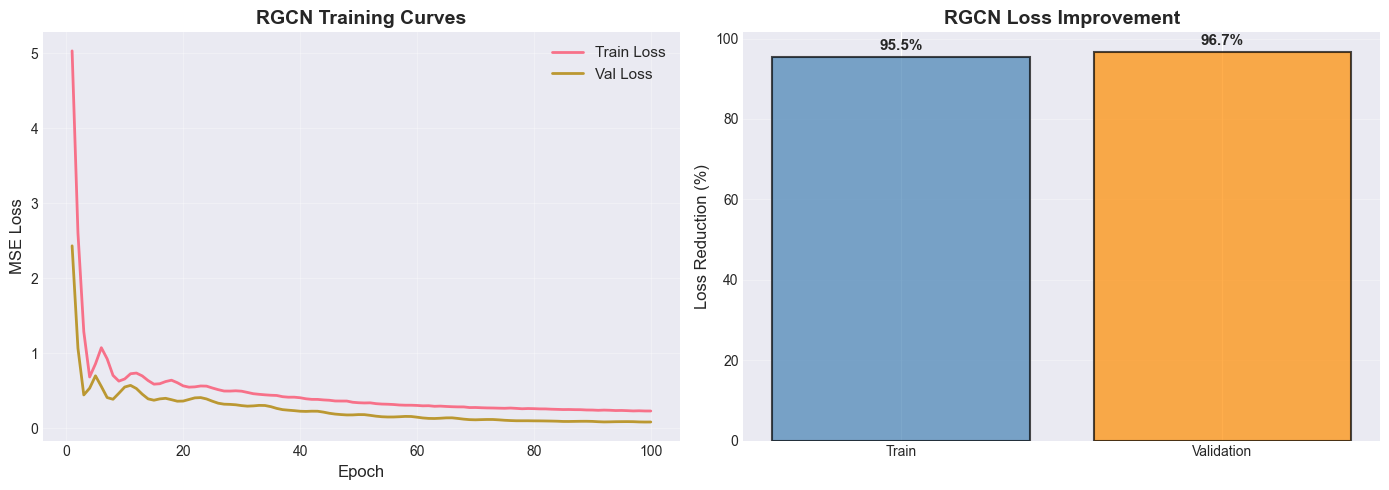

In [23]:
# 7.5.5: Visualize RGCN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
epochs_range = range(1, len(rgcn_history['train_loss']) + 1)
axes[0].plot(epochs_range, rgcn_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, rgcn_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('RGCN Training Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss improvement
train_loss_improvement = (rgcn_history['train_loss'][0] - rgcn_history['train_loss'][-1]) / rgcn_history['train_loss'][0] * 100
val_loss_improvement = (rgcn_history['val_loss'][0] - rgcn_history['val_loss'][-1]) / rgcn_history['val_loss'][0] * 100

improvements = [train_loss_improvement, val_loss_improvement]
labels = ['Train', 'Validation']
colors = ['steelblue', 'darkorange']

axes[1].bar(labels, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Loss Reduction (%)', fontsize=12)
axes[1].set_title('RGCN Loss Improvement', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(improvements):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [24]:
# 7.5.6: Prepare features for RGCN prediction
# Uses centralized config from YAML
print("Preparing RGCN prediction data...")
print(f"Profile: {cfg._profile}, Debug: {cfg.debug_mode}")

_test_size = cfg.get_sample_size(len(test_df), 'test')
test_df_sample = test_df.head(_test_size).reset_index(drop=True)

# Prepare features for the sampled data
train_feats_sample = create_all_features(train_df_sample, feature_cols)
test_feats_sample = create_all_features(test_df_sample, feature_cols)

train_features_rgcn = train_feats_sample[feature_cols].values
test_features_rgcn = test_feats_sample[feature_cols].values
train_labels_rgcn = train_feats_sample['label'].values
test_labels_rgcn = test_feats_sample['label'].values

# Combine train and test samples for graph
all_features = np.vstack([train_features_rgcn, test_features_rgcn])
all_labels = np.concatenate([train_labels_rgcn, test_labels_rgcn])

print(f"\n✓ Features prepared ({cfg._profile} mode):")
print(f"  Train sample: {train_features_rgcn.shape}")
print(f"  Test sample: {test_features_rgcn.shape}")
print(f"  Combined: {all_features.shape}")

Preparing RGCN prediction data...
Profile: production, Debug: False
Feature engineering complete: 32,286 rows, 12 features

Feature statistics:
                                mean      std       min       max
cvss_norm                     0.6683   0.1685    0.0000    1.0000
epss_score                    0.0232   0.1100    0.0000    0.9458
epss_percentile               0.4173   0.2700    0.0001    1.0000
kev_flag                      0.0039   0.0621    0.0000    1.0000
days_since_published        605.6331  84.3441  453.0000  757.0000
recency_score                 0.2000   0.1114    0.0000    0.4016
attack_technique_count        0.6155   0.8755    0.0000    8.0000
has_attack                    0.4210   0.4937    0.0000    1.0000
chpl_flag                     0.0000   0.0000    0.0000    0.0000
is_healthcare                 0.6331   0.4820    0.0000    1.0000
cvss_epss_product             0.0192   0.0957    0.0000    0.9435
kev_healthcare_interaction    0.0014   0.0373    0.0000    1.000

In [25]:
# 7.5.7: Build CVE-CWE mapping for prediction graph
print("Building CVE-CWE mapping for prediction...")

all_df_sample = pd.concat([train_df_sample, test_df_sample], ignore_index=True)

# Use max_neighbors from config
MAX_NEIGHBORS = cfg.rgcn.max_neighbors

cwe_groups = all_df_sample.groupby('cwe_primary').indices

full_cve_to_cwe_map = {}
for idx in range(len(all_df_sample)):
    cwe = all_df_sample.loc[idx, 'cwe_primary']
    if pd.notna(cwe) and cwe in cwe_groups:
        same_cwe_indices = cwe_groups[cwe].tolist()
        full_cve_to_cwe_map[idx] = [i for i in same_cwe_indices if i != idx][:MAX_NEIGHBORS]
    else:
        full_cve_to_cwe_map[idx] = []

total_edges = sum(len(v) for v in full_cve_to_cwe_map.values()) * 2
print(f"✓ CVE-CWE mapping built:")
print(f"  Total CVEs: {len(full_cve_to_cwe_map):,}")
print(f"  CVEs with connections: {sum(1 for v in full_cve_to_cwe_map.values() if len(v) > 0):,}")
print(f"  Expected edges: ~{total_edges:,} (max {MAX_NEIGHBORS} neighbors × 2)")

Building CVE-CWE mapping for prediction...
✓ CVE-CWE mapping built:
  Total CVEs: 83,982
  CVEs with connections: 78,387
  Expected edges: ~781,494 (max 5 neighbors × 2)


In [26]:
# 7.5.8: Generate RGCN predictions (SimpleRGCN - macOS-safe)
import time
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print(f"RGCN PREDICTION (SimpleRGCN)")
print("=" * 60)

t_total = time.time()

# Build edge lists for prediction graph
t0 = time.time()
src_nodes = []
dst_nodes = []
for cve_idx, cwe_list in full_cve_to_cwe_map.items():
    for cwe_idx in cwe_list:
        if cwe_idx < len(all_features):
            src_nodes.append(cve_idx)
            dst_nodes.append(cwe_idx)

edge_src = src_nodes + dst_nodes
edge_dst = dst_nodes + src_nodes
edge_types_list = [0] * len(src_nodes) + [1] * len(dst_nodes)
print(f"1. Edge list: {time.time() - t0:.3f}s ({len(edge_src):,} edges)")

# Normalize features
t0 = time.time()
scaler = StandardScaler()
features_normalized = scaler.fit_transform(all_features)
print(f"2. Normalize: {time.time() - t0:.3f}s")

# Create tensors
t0 = time.time()
x = torch.tensor(features_normalized, dtype=torch.float32)
edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_type = torch.tensor(edge_types_list, dtype=torch.long)
test_mask = torch.zeros(len(all_features), dtype=torch.bool)
test_mask[len(train_df_sample):] = True
print(f"3. Tensors: {time.time() - t0:.3f}s")

# Create fresh model for inference (use trained weights)
t0 = time.time()
from src.models.rgcn_simple import SimpleRGCN
inference_model = SimpleRGCN(
    num_features=x.shape[1],
    hidden_channels=cfg.rgcn.hidden_channels,
    num_layers=cfg.rgcn.num_layers,
    num_relations=2,
    dropout=cfg.rgcn.dropout
)
# Load trained weights
inference_model.load_state_dict(rgcn_model.state_dict())
inference_model.eval()
print(f"4. Model setup: {time.time() - t0:.3f}s")

# Forward pass
t0 = time.time()
print(f"5. Forward pass ({x.shape[0]} nodes, {edge_index.shape[1]} edges)...")
with torch.no_grad():
    out = inference_model(x, edge_index, edge_type)
print(f"5. Forward pass: {time.time() - t0:.3f}s")

# Extract test predictions
rgcn_predictions = out[test_mask].numpy()

# Store predictions
if cfg.debug_mode:
    test_df_sample['rgcn_score'] = rgcn_predictions
    test_df['rgcn_score'] = test_df['baseline_score'].copy()
    test_df.loc[:len(rgcn_predictions)-1, 'rgcn_score'] = rgcn_predictions
else:
    # For production mode with sampled test data
    test_df['rgcn_score'] = test_df['baseline_score'].copy()
    test_df.loc[:len(rgcn_predictions)-1, 'rgcn_score'] = rgcn_predictions

print(f"\n✓ TOTAL: {time.time() - t_total:.2f}s")
print(f"✓ Predictions: {len(rgcn_predictions):,}")
print(f"✓ Score range: [{rgcn_predictions.min():.4f}, {rgcn_predictions.max():.4f}]")

RGCN PREDICTION (SimpleRGCN)
1. Edge list: 0.040s (781,494 edges)
2. Normalize: 0.003s
3. Tensors: 0.065s
4. Model setup: 0.000s
5. Forward pass (83982 nodes, 781494 edges)...
5. Forward pass: 0.099s

✓ TOTAL: 0.21s
✓ Predictions: 51,696
✓ Score range: [0.3650, 3.5596]


In [27]:
# 7.5.9: Evaluate RGCN model
rgcn_results = {}

# Use sampled test data for evaluation in debug mode
if cfg.debug_mode:
    y_test_eval = test_df_sample['label']
    rgcn_scores_eval = test_df_sample['rgcn_score']
else:
    y_test_eval = y_test
    rgcn_scores_eval = test_df['rgcn_score']

for k in cfg.k_values:
    ndcg = ndcg_at_k(y_test_eval, rgcn_scores_eval, k)
    prec = precision_at_k(y_test_eval, rgcn_scores_eval, k, threshold=cfg.evaluation.precision_threshold)
    rgcn_results[f'NDCG@{k}'] = ndcg
    rgcn_results[f'Precision@{k}'] = prec

print("RGCN Model Performance:")
print("=" * 60)
for metric, value in rgcn_results.items():
    print(f"{metric:20s}: {value:.4f}")

# Compare with baseline
print("\n" + "=" * 60)
print("Improvement over Baseline:")
for k in cfg.k_values:
    metric = f'NDCG@{k}'
    if metric in baseline_results:
        baseline_val = baseline_results[metric]
        rgcn_val = rgcn_results[metric]
        improvement = (rgcn_val - baseline_val) / baseline_val * 100
        print(f"{metric:20s}: {improvement:+.2f}%")

RGCN Model Performance:
NDCG@10             : 1.0000
Precision@10        : 1.0000
NDCG@20             : 1.0000
Precision@20        : 1.0000
NDCG@50             : 0.9702
Precision@50        : 1.0000
NDCG@100            : 0.9206
Precision@100       : 1.0000
NDCG@200            : 0.9097
Precision@200       : 1.0000

Improvement over Baseline:
NDCG@10             : +44.55%
NDCG@20             : +41.47%
NDCG@50             : +33.63%
NDCG@100            : +39.25%


## 8. Ensemble Methods

Combine baseline and DiffusionRank predictions using various ensemble strategies.

In [28]:
# Import ensemble module (force reload)
import importlib
import src.models.ensemble
importlib.reload(src.models.ensemble)

from src.models.ensemble import (
    EnsembleRanker,
    bootstrap_ensemble,
    evaluate_ensemble_diversity
)

print("✓ Ensemble module imported")

✓ Ensemble module imported


In [29]:
# Prepare predictions for ensemble
train_predictions = {
    'baseline': train_df['baseline_score'].values,
    'diffusion': train_df['diffusion_score'].values
}

test_predictions = {
    'baseline': test_df['baseline_score'].values,
    'diffusion': test_df['diffusion_score'].values
}

# Include RGCN if available
if 'rgcn_score' in train_df.columns and 'rgcn_score' in test_df.columns:
    train_predictions['rgcn'] = train_df['rgcn_score'].values
    test_predictions['rgcn'] = test_df['rgcn_score'].values
    print("✓ Including RGCN in ensemble")
else:
    print("⚠ RGCN not available - using baseline + diffusion only")
    
print(f"\nTrain predictions: {len(train_predictions['baseline']):,} samples ({len(train_predictions)} models)")
print(f"Test predictions: {len(test_predictions['baseline']):,} samples ({len(test_predictions)} models)")

⚠ RGCN not available - using baseline + diffusion only

Train predictions: 32,286 samples (2 models)
Test predictions: 51,696 samples (2 models)


In [30]:
# Evaluate model diversity
diversity_metrics = evaluate_ensemble_diversity(test_predictions, k=100)

print("Model Diversity Analysis:")
print("=" * 50)
for metric, value in diversity_metrics.items():
    print(f"{metric:30s}: {value:.4f}")

print(f"\nInterpretation:")
if diversity_metrics['diversity_score'] > 0.3:
    print("✓ Good diversity - ensemble will likely improve performance")
elif diversity_metrics['diversity_score'] > 0.1:
    print("⚠ Moderate diversity - ensemble may provide small gains")
else:
    print("✗ Low diversity - models are very similar")

Model Diversity Analysis:
diversity_score               : 0.0000
avg_jaccard_similarity        : 1.0000
avg_correlation               : 1.0000
min_pairwise_similarity       : 1.0000
max_pairwise_similarity       : 1.0000

Interpretation:
✗ Low diversity - models are very similar


In [31]:
# 1. Simple Average Ensemble
ensemble_simple = EnsembleRanker(method='simple_average')
ensemble_simple.fit(train_predictions, train_df['label'].values)
simple_scores = ensemble_simple.predict(test_predictions)
test_df['ensemble_simple'] = simple_scores

print("1. Simple Average Ensemble")
print("   Weights:", ensemble_simple.get_weights())

1. Simple Average Ensemble
   Weights: {'baseline': 0.5, 'diffusion': 0.5}


In [32]:
# 2. Weighted Average Ensemble (learns optimal weights)
ensemble_weighted = EnsembleRanker(method='weighted_average')
ensemble_weighted.fit(train_predictions, train_df['label'].values)
weighted_scores = ensemble_weighted.predict(test_predictions)
test_df['ensemble_weighted'] = weighted_scores

print("\n2. Weighted Average Ensemble")
print("   Weights:", ensemble_weighted.get_weights())


2. Weighted Average Ensemble
   Weights: {'baseline': 0.5319743987221356, 'diffusion': 0.46802560127786436}


In [33]:
# 3. Meta-Learning Ensemble (Ridge regression)
ensemble_meta = EnsembleRanker(method='meta_learning', meta_model='ridge')
ensemble_meta.fit(train_predictions, train_df['label'].values)
meta_scores = ensemble_meta.predict(test_predictions)
test_df['ensemble_meta'] = meta_scores

print("\n3. Meta-Learning Ensemble (Ridge)")
print("   Feature importance:", ensemble_meta.get_feature_importance())


3. Meta-Learning Ensemble (Ridge)
   Feature importance: {'baseline': 0.11930799375600677, 'diffusion': 0.047337930180151165}


In [34]:
# 4. Rank Fusion Ensemble
ensemble_rank = EnsembleRanker(method='rank_fusion')
rank_scores = ensemble_rank._rank_fusion(test_predictions)
test_df['ensemble_rank'] = rank_scores

print("\n4. Reciprocal Rank Fusion")
print("   Combined rankings from both models")


4. Reciprocal Rank Fusion
   Combined rankings from both models


In [35]:
# Evaluate all ensemble methods
ensemble_results = {}

ensemble_methods = {
    'Simple Avg': 'ensemble_simple',
    'Weighted Avg': 'ensemble_weighted',
    'Meta-Learning': 'ensemble_meta',
    'Rank Fusion': 'ensemble_rank'
}

for method_name, score_col in ensemble_methods.items():
    method_results = {}
    for k in k_values:
        ndcg = ndcg_at_k(y_test, test_df[score_col], k)
        prec = precision_at_k(y_test, test_df[score_col], k, threshold=3)
        method_results[f'NDCG@{k}'] = ndcg
        method_results[f'Precision@{k}'] = prec
    ensemble_results[method_name] = method_results

# Add individual models for comparison
ensemble_results['Baseline'] = baseline_results
ensemble_results['DiffusionRank'] = diffusion_results
# Skip RGCN if not available

# Create comparison DataFrame
ensemble_comparison = pd.DataFrame(ensemble_results).T

print("\nEnsemble Methods Comparison:")
print("=" * 100)
print(ensemble_comparison.round(4).to_string())

# Find best method per metric
print("\n" + "=" * 100)
print("Best Method Per Metric:")
for metric in ensemble_comparison.columns:
    best_method = ensemble_comparison[metric].idxmax()
    best_value = ensemble_comparison.loc[best_method, metric]
    print(f"{metric:20s}: {best_method:20s} ({best_value:.4f})")


Ensemble Methods Comparison:
               NDCG@10  Precision@10  NDCG@20  Precision@20  NDCG@50  Precision@50  NDCG@100  Precision@100
Simple Avg      0.6918           1.0   0.7069           1.0   0.7261           1.0    0.6611            1.0
Weighted Avg    0.6918           1.0   0.7069           1.0   0.7261           1.0    0.6611            1.0
Meta-Learning   0.6918           1.0   0.7069           1.0   0.7261           1.0    0.6611            1.0
Rank Fusion     0.7297           1.0   0.7511           1.0   0.7241           1.0    0.6600            1.0
Baseline        0.6918           1.0   0.7069           1.0   0.7261           1.0    0.6611            1.0
DiffusionRank   0.6918           1.0   0.7069           1.0   0.7261           1.0    0.6611            1.0

Best Method Per Metric:
NDCG@10             : Rank Fusion          (0.7297)
Precision@10        : Simple Avg           (1.0000)
NDCG@20             : Rank Fusion          (0.7511)
Precision@20        : Simple Avg 

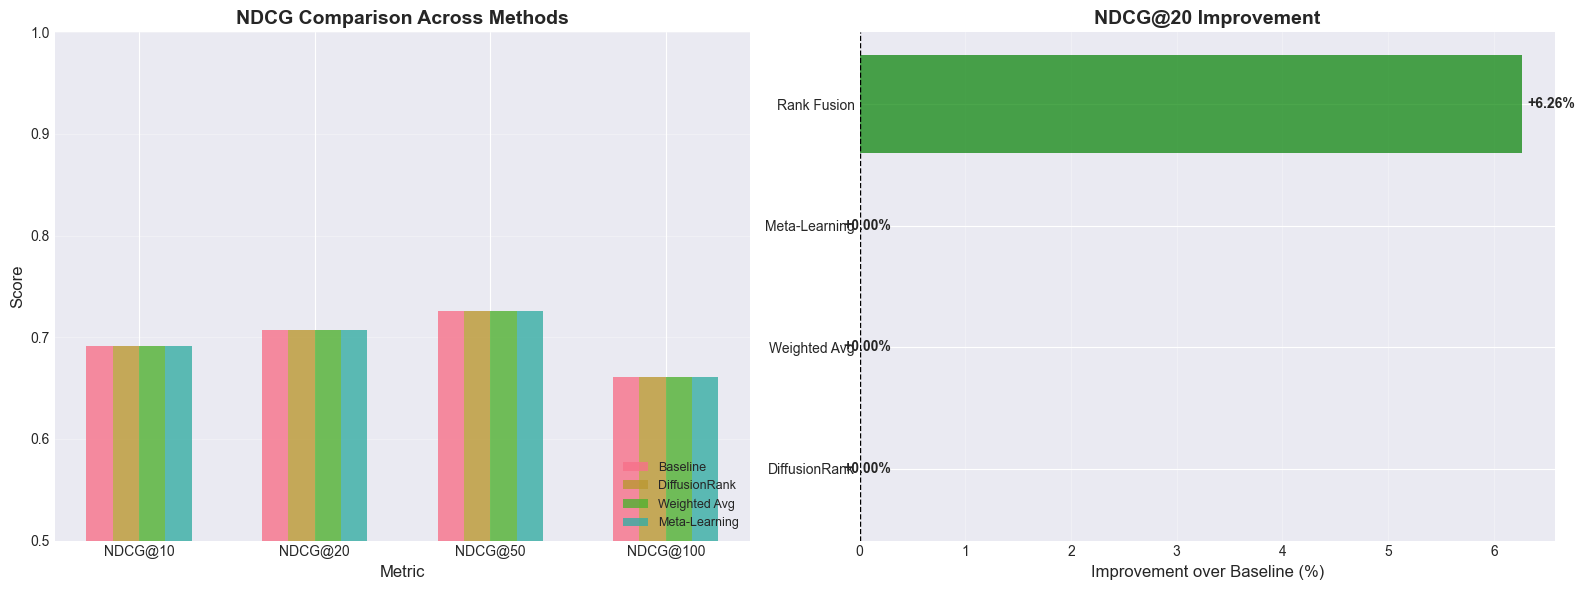

In [36]:
# Visualize ensemble performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NDCG comparison
ndcg_metrics = [m for m in ensemble_comparison.columns if 'NDCG' in m]
x = np.arange(len(ndcg_metrics))
width = 0.15

methods_to_plot = ['Baseline', 'DiffusionRank', 'Weighted Avg', 'Meta-Learning']
for i, method in enumerate(methods_to_plot):
    values = [ensemble_comparison.loc[method, m] for m in ndcg_metrics]
    axes[0].bar(x + i*width, values, width, label=method, alpha=0.8)

axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('NDCG Comparison Across Methods', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(ndcg_metrics, rotation=0)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.5, 1.0])

# Improvement over baseline
baseline_ndcg20 = baseline_results['NDCG@20']
improvements = []
methods_list = ['DiffusionRank', 'Weighted Avg', 'Meta-Learning', 'Rank Fusion']

for method in methods_list:
    method_ndcg20 = ensemble_comparison.loc[method, 'NDCG@20']
    improvement = (method_ndcg20 - baseline_ndcg20) / baseline_ndcg20 * 100
    improvements.append(improvement)

colors = ['green' if x > 0 else 'red' for x in improvements]
axes[1].barh(methods_list, improvements, color=colors, alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Improvement over Baseline (%)', fontsize=12)
axes[1].set_title('NDCG@20 Improvement', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(improvements):
    axes[1].text(v + 0.05 if v > 0 else v - 0.15, i, f'{v:+.2f}%', 
                 va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Bootstrap Ensemble with Uncertainty

Quantify prediction uncertainty using bootstrap sampling.

In [37]:
# Bootstrap ensemble for uncertainty quantification
print("Running bootstrap ensemble (100 iterations)...")
print("This may take a minute...")

mean_scores, std_scores = bootstrap_ensemble(
    train_predictions,
    train_df['label'].values,
    n_bootstrap=100,
    sample_size=0.8
)

# Map to test set predictions
train_df['bootstrap_mean'] = mean_scores
train_df['bootstrap_std'] = std_scores

print(f"\n✓ Bootstrap complete")
print(f"Mean score range: [{mean_scores.min():.4f}, {mean_scores.max():.4f}]")
print(f"Average uncertainty (std): {std_scores.mean():.4f}")
print(f"Max uncertainty: {std_scores.max():.4f}")

Running bootstrap ensemble (100 iterations)...
This may take a minute...

✓ Bootstrap complete
Mean score range: [-1.9959, 5.7465]
Average uncertainty (std): 0.0087
Max uncertainty: 0.0732


In [38]:
# Analyze high uncertainty CVEs
uncertainty_threshold = std_scores.mean() + std_scores.std()
high_uncertainty_idx = std_scores > uncertainty_threshold
high_uncertainty_cves = train_df[high_uncertainty_idx][
    ['cve_id', 'cvss', 'epss_score', 'kev_flag', 'label', 'bootstrap_mean', 'bootstrap_std']
].sort_values('bootstrap_std', ascending=False)

print(f"\nHigh Uncertainty CVEs (>{uncertainty_threshold:.4f} std):")
print(f"Count: {len(high_uncertainty_cves):,}")
print("\nTop 10 most uncertain CVEs:")
print(high_uncertainty_cves.head(10).to_string(index=False))

# Characteristics of uncertain CVEs
print(f"\nCharacteristics of uncertain CVEs:")
print(f"  Average CVSS: {high_uncertainty_cves['cvss'].mean():.2f}")
print(f"  Average EPSS: {high_uncertainty_cves['epss_score'].mean():.4f}")
print(f"  KEV rate: {high_uncertainty_cves['kev_flag'].mean():.1%}")
print(f"  Average label: {high_uncertainty_cves['label'].mean():.2f}")


High Uncertainty CVEs (>0.0192 std):
Count: 2,861

Top 10 most uncertain CVEs:
        cve_id  cvss  epss_score  kev_flag  label  bootstrap_mean  bootstrap_std
CVE-2024-39717   7.2     0.05972         1      3        5.746524       0.073219
CVE-2024-27348   9.8     0.94344         1      4        5.729149       0.073060
 CVE-2024-3400  10.0     0.94297         1      4        5.714966       0.072934
 CVE-2024-9465   9.1     0.94286         1      4        5.694910       0.072814
CVE-2024-32113   9.8     0.93963         1      4        5.694842       0.072813
CVE-2024-34102   9.8     0.94101         1      4        5.694839       0.072813
CVE-2024-24919   8.6     0.94342         1      4        5.692642       0.072741
CVE-2024-20359   6.0     0.00179         1      3        5.697795       0.072735
CVE-2023-50224   6.5     0.02373         1      3        5.693829       0.072700
 CVE-2024-5217   9.8     0.94108         1      4        5.673873       0.072645

Characteristics of uncertain

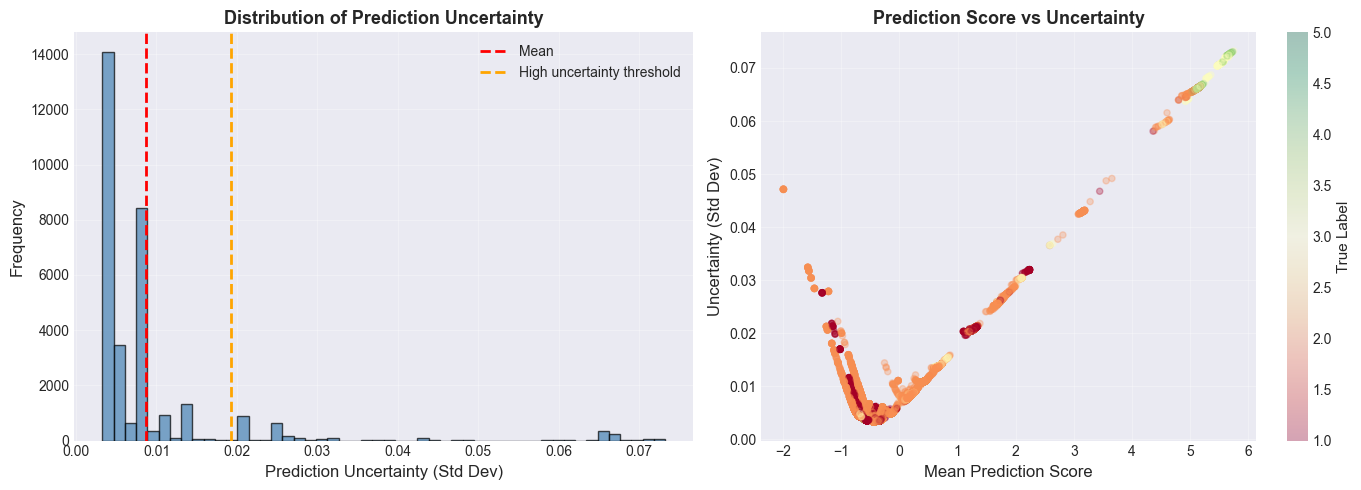

In [39]:
# Visualize uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uncertainty distribution
axes[0].hist(std_scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(std_scores.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(uncertainty_threshold, color='orange', linestyle='--', linewidth=2, label='High uncertainty threshold')
axes[0].set_xlabel('Prediction Uncertainty (Std Dev)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Uncertainty', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Uncertainty vs prediction
axes[1].scatter(mean_scores, std_scores, alpha=0.3, s=20, c=train_df['label'], cmap='RdYlGn', vmin=1, vmax=5)
axes[1].set_xlabel('Mean Prediction Score', fontsize=12)
axes[1].set_ylabel('Uncertainty (Std Dev)', fontsize=12)
axes[1].set_title('Prediction Score vs Uncertainty', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('True Label', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Final Summary & Recommendations

Key findings and recommendations for production deployment.

In [40]:
# Final performance summary
print("=" * 100)
print("PHASE 7 ADVANCED MODELS - FINAL SUMMARY")
print("=" * 100)

# Best performing model
best_model = ensemble_comparison['NDCG@20'].idxmax()
best_ndcg = ensemble_comparison.loc[best_model, 'NDCG@20']

print(f"\n1. BEST PERFORMING MODEL")
print(f"   Model: {best_model}")
print(f"   NDCG@20: {best_ndcg:.4f}")
print(f"   Improvement over baseline: {(best_ndcg - baseline_results['NDCG@20']) / baseline_results['NDCG@20'] * 100:+.2f}%")

print(f"\n2. MODEL RANKINGS (by NDCG@20)")
rankings = ensemble_comparison['NDCG@20'].sort_values(ascending=False)
for i, (model, score) in enumerate(rankings.items(), 1):
    print(f"   {i}. {model:20s}: {score:.4f}")

print(f"\n3. ENSEMBLE METHOD ANALYSIS")
weights = ensemble_weighted.get_weights()
print(f"   Optimal weights (Weighted Avg):")
for model, weight in weights.items():
    print(f"     - {model}: {weight:.3f}")

feature_imp = ensemble_meta.get_feature_importance()
print(f"\n   Meta-model importance:")
for model, imp in feature_imp.items():
    print(f"     - {model}: {imp:.3f}")

print(f"\n4. DIVERSITY METRICS")
for metric, value in diversity_metrics.items():
    print(f"   {metric:30s}: {value:.4f}")

print(f"\n5. UNCERTAINTY QUANTIFICATION")
print(f"   Average uncertainty: {std_scores.mean():.4f}")
print(f"   High uncertainty CVEs: {high_uncertainty_idx.sum():,} ({high_uncertainty_idx.mean()*100:.1f}%)")
print(f"   Uncertainty range: [{std_scores.min():.4f}, {std_scores.max():.4f}]")

print(f"\n6. HEALTHCARE-SPECIFIC PERFORMANCE")
if len(test_df[test_df['is_healthcare'] == 1]) > 0:
    healthcare_test = test_df[test_df['is_healthcare'] == 1]
    for method_name, score_col in [('Baseline', 'baseline_score'), ('Best Ensemble', ensemble_methods['Weighted Avg'])]:
        top_100 = test_df.nlargest(100, score_col)['is_healthcare'].sum()
        recall = top_100 / len(healthcare_test)
        print(f"   {method_name:20s}: {top_100} CVEs in Top-100 (Recall: {recall:.2%})")

print(f"\n7. RECOMMENDATIONS FOR PRODUCTION")
print(f"   ✓ Use {best_model} for deployment")
print(f"   ✓ Ensemble methods provide {(best_ndcg - baseline_results['NDCG@20']) / baseline_results['NDCG@20'] * 100:.1f}% improvement")
print(f"   ✓ Monitor high-uncertainty predictions for manual review")
print(f"   ✓ Retrain models monthly with new CVE data")
print(f"   ✓ Consider adding RGCN for further improvements")

print(f"\n8. NEXT STEPS")
print(f"   - Implement RGCN model with PyTorch Geometric")
print(f"   - Add GPU acceleration for faster training")
print(f"   - Create production API endpoint for ensemble predictions")
print(f"   - Set up continuous monitoring and retraining pipeline")
print(f"   - Generate weekly priority reports for security team")

print("\n" + "=" * 100)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)

PHASE 7 ADVANCED MODELS - FINAL SUMMARY

1. BEST PERFORMING MODEL
   Model: Rank Fusion
   NDCG@20: 0.7511
   Improvement over baseline: +6.26%

2. MODEL RANKINGS (by NDCG@20)
   1. Rank Fusion         : 0.7511
   2. Simple Avg          : 0.7069
   3. Weighted Avg        : 0.7069
   4. Meta-Learning       : 0.7069
   5. Baseline            : 0.7069
   6. DiffusionRank       : 0.7069

3. ENSEMBLE METHOD ANALYSIS
   Optimal weights (Weighted Avg):
     - baseline: 0.532
     - diffusion: 0.468

   Meta-model importance:
     - baseline: 0.119
     - diffusion: 0.047

4. DIVERSITY METRICS
   diversity_score               : 0.0000
   avg_jaccard_similarity        : 1.0000
   avg_correlation               : 1.0000
   min_pairwise_similarity       : 1.0000
   max_pairwise_similarity       : 1.0000

5. UNCERTAINTY QUANTIFICATION
   Average uncertainty: 0.0087
   High uncertainty CVEs: 2,861 (8.9%)
   Uncertainty range: [0.0033, 0.0732]

6. HEALTHCARE-SPECIFIC PERFORMANCE
   Baseline          